# Voice Denoising via SVD on Hankel Matrices — Pipeline v1

End-to-end pipeline:
1. Load clean audio from `data/clean/`
2. Add artificial white Gaussian noise at a target input SNR
3. Build a Hankel matrix from the noisy signal
4. Apply truncated SVD
5. Reconstruct signal via anti-diagonal averaging
6. Save denoised output and evaluate SNR against the clean reference

In [ ]:
import numpy as np
import scipy.linalg as la
import librosa
import soundfile as sf
from pathlib import Path

In [ ]:
# --- Configuration ---
RECORDING_NAME = "recording_011_male"
TARGET_INPUT_SNR_DB = 5.0
NOISE_SEED = 0
K_RANK = 300  # number of singular values to keep
L = 1000

def define_name(recording_name, window_length, k_rank, input_snr_db=None, is_filtered=False):
    snr_tag = "" if input_snr_db is None else f"-snr{input_snr_db:g}"
    filter_tag = "-filtered" if is_filtered else ""
    return f"{recording_name}{snr_tag}-wl{window_length}-k{k_rank}-denoised{filter_tag}.wav"


# --- Input/Output ---
INPUT_PATH = f"data/clean/{RECORDING_NAME}.wav"
NOISY_OUTPUT_PATH = f"data/output/awgn/{RECORDING_NAME}-snr{TARGET_INPUT_SNR_DB:g}-noisy.wav"

## 1. Load audio

In [3]:
# Load clean input, then create artificial AWGN for the denoising pipeline.
clean_signal, sr = librosa.load(INPUT_PATH, sr=None, mono=True)
clean_signal = clean_signal.astype(np.float64)


def snr_db(reference, error):
    """Standard SNR: 10 log10(power(reference) / power(error))."""
    signal_power = np.mean(reference.astype(np.float64) ** 2)
    error_power = np.mean(error.astype(np.float64) ** 2)
    return np.inf if error_power == 0 else 10 * np.log10(signal_power / error_power)


def make_awgn(clean, target_snr_db, seed):
    rng = np.random.default_rng(seed)
    raw_noise = rng.standard_normal(clean.shape)
    raw_noise -= raw_noise.mean()

    signal_power = np.mean(clean**2)
    target_noise_power = signal_power / (10 ** (target_snr_db / 10))
    return raw_noise / np.sqrt(np.mean(raw_noise**2)) * np.sqrt(target_noise_power)


artificial_noise = make_awgn(clean_signal, TARGET_INPUT_SNR_DB, NOISE_SEED)
signal = clean_signal + artificial_noise
input_snr_db = snr_db(clean_signal, artificial_noise)

Path(NOISY_OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
sf.write(NOISY_OUTPUT_PATH, np.clip(signal, -1.0, 1.0).astype(np.float32), sr)

print(f"Sample rate       : {sr} Hz")
print(f"Duration          : {len(signal)/sr:.2f} s  ({len(signal)} samples)")
print(f"Clean dtype       : {clean_signal.dtype}")
print(f"Clean amplitude   : [{clean_signal.min():.4f}, {clean_signal.max():.4f}]")
print(f"Noisy amplitude   : [{signal.min():.4f}, {signal.max():.4f}]")
print(f"Target input SNR  : {TARGET_INPUT_SNR_DB:+.2f} dB")
print(f"Actual input SNR  : {input_snr_db:+.2f} dB")
print(f"Saved noisy input : {NOISY_OUTPUT_PATH}")

Sample rate       : 16000 Hz
Duration          : 6.54 s  (104611 samples)
Clean dtype       : float64
Clean amplitude   : [-0.4887, 0.5025]
Noisy amplitude   : [-0.5705, 0.5713]
Target input SNR  : +5.00 dB
Actual input SNR  : +5.00 dB
Saved noisy input : data/output/awgn/recording_011_male-snr5-noisy.wav


In [4]:
def compute_L(signal, sr):
    N = len(signal)
    
    # Hard constraints
    L_max_allowed = N // 2
    
    # Target: 100ms, but scale with signal
    L_target = int(sr * 0.1)  # 100ms
    
    # For very short signals, back off to 50ms
    if N < sr * 0.5:  # under 500ms
        L_target = int(sr * 0.05)
    
    # Never exceed N/2
    L = min(L_target, L_max_allowed)
    
    return L

L = compute_L(signal, sr)

def k_from_energy(S, threshold=0.95):
    # Singular values: energy ∝ σ²
    # But normalize AFTER squaring so proportions are correct
    sv_energy = S**2
    total = sv_energy.sum()
    cumulative = np.cumsum(sv_energy) / total
    
    k = np.searchsorted(cumulative, threshold) + 1
    k = np.clip(k, 1, len(S))
    
    print(f"k={k} / {len(S)} → {cumulative[k-1]*100:.1f}% energy")
    return k


## 2. Hankel matrix composition

Given a signal $x = (x_1, \dots, x_N)$ and window length $L$, the Hankel matrix is

$$
H_{ij} = x_{i+j-1}, \quad i = 1,\dots,L,\; j = 1,\dots,K,\; K = N - L + 1.
$$

Each anti-diagonal holds the same sample index, which is the key property exploited during reconstruction.

In [5]:
def build_hankel(x: np.ndarray, L: int) -> np.ndarray:
    """Construct the L x (N-L+1) Hankel embedding matrix."""
    N = len(x)
    K = N - L + 1
    if K < 1:
        raise ValueError(f"Window length L={L} exceeds signal length N={N}.")
    # Use stride tricks for zero-copy construction
    shape   = (L, K)
    strides = (x.strides[0], x.strides[0])
    return np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)


def hankel_to_signal(Hk: np.ndarray) -> np.ndarray:
    """Anti-diagonal averaging: recover 1-D signal from a (possibly non-Hankel) matrix."""
    L, K = Hk.shape
    N = L + K - 1
    out = np.zeros(N)
    counts = np.zeros(N)
    for i in range(L):
        out[i : i + K]    += Hk[i, :]
        counts[i : i + K] += 1
    return out / counts


H = build_hankel(signal, L)
print(f"Hankel matrix shape : {H.shape}  (L={L}, K={H.shape[1]})")
print(f"Memory (view)       : {H.nbytes / 1e6:.1f} MB")

Hankel matrix shape : (1600, 103012)  (L=1600, K=103012)
Memory (view)       : 1318.6 MB


## 3. SVD algorithm application

Compute the full SVD $H = U \Sigma V^T$ and retain only the top-$k$ components:

$$
H_k = \sum_{i=1}^{k} \sigma_i \, u_i v_i^T.
$$

In [6]:
# Economy / thin SVD: full_matrices=False keeps U, Vt shapes manageable.
# We copy H because as_strided returns a read-only view.
# On CUDA (e.g. T4), use PyTorch; otherwise SciPy on CPU.
H_copy = np.array(H, dtype=np.float64)

U, s, Vt = la.svd(H_copy, full_matrices=False)

print(f"U  shape : {U.shape}")
print(f"s  shape : {s.shape}  (total singular values)")
print(f"Vt shape : {Vt.shape}")
print(f"\nTop-10 singular values : {s[:10].round(2)}")
K_RANK = k_from_energy(s, threshold=0.95)
OUTPUT_PATH = f"data/output/awgn/{define_name(RECORDING_NAME, L, K_RANK, input_snr_db=TARGET_INPUT_SNR_DB, is_filtered=True)}"
print(f"Energy captured by top-{K_RANK}: {(s[:K_RANK]**2).sum() / (s**2).sum() * 100:.1f} %")

U  shape : (1600, 1600)
s  shape : (1600,)  (total singular values)
Vt shape : (1600, 103012)

Top-10 singular values : [214.24 213.72 176.42 175.67 160.79 160.32 153.26 152.3  149.96 149.9 ]
k=1232 / 1600 → 95.0% energy
Energy captured by top-1232: 95.0 %


### SVD from scratch(+check)

In [8]:
def manual_norm(v):
    """Calculates Euclidean norm: sqrt(sum of squares)"""
    return np.sqrt(np.sum(v**2))

def power_iteration(C, max_iter=10000, tol=1e-7):
    """Finds the dominant eigenvector and eigenvalue of a symmetric matrix C"""
    # Start with a random vector
    n = C.shape[0]
    y_old = np.random.rand(n)
    y_old = y_old / manual_norm(y_old)
    
    for i in range(max_iter):
        y_new = C @ y_old
        y_new_norm = manual_norm(y_new)
        
        # Avoid division by zero
        if y_new_norm < 1e-15:
            return y_new, 0
            
        y_new = y_new / y_new_norm
        
        # Check convergence
        if manual_norm(y_new - y_old) < tol:
            break
            
        y_old = y_new
        
    # Rayleigh Quotient for the eigenvalue: (u^T * C * u) / (u^T * u)
    # Since ||u|| = 1, it is just u^T * C * u
    eigenvalue = y_new.T @ C @ y_new
    return y_new, eigenvalue

def manual_svd(A, k_rank):
    """
    Implements SVD from scratch using Power Iteration and Hotelling's Deflation.
    Returns U (L x k), sigma (k,), and Vt (k x K)
    """
    L, K_cols = A.shape
    # We work with the covariance matrix C = A * A.T (size L x L)
    # This is much smaller than A * A.T if we used the other direction
    C = A @ A.T 
    
    U_cols = []
    singular_values = []
    V_rows = []
    
    # Copy C to avoid modifying the original matrix during deflation
    C_current = np.array(C, copy=True)
    
    for i in range(k_rank):
        # 1. Find dominant eigenvector (ui) and eigenvalue (lambda_i)
        ui, lmbda = power_iteration(C_current)
        
        # 2. Calculate singular value: sigma = sqrt(lambda)
        # Ensure lmbda is non-negative (numerical precision fix)
        sigma = np.sqrt(max(0, lmbda))
        
        if sigma < 1e-12: # Handle rank-deficient cases
            break
            
        # 3. Calculate corresponding v_i: vi = (1/sigma) * A.T * ui
        vi = (A.T @ ui) / sigma
        
        # 4. Deflation: Remove this component from C_current
        # C_next = C_current - lambda * (ui * ui.T)
        C_current = C_current - lmbda * np.outer(ui, ui)
        
        # Store results
        U_cols.append(ui)
        singular_values.append(sigma)
        V_rows.append(vi)
        
        if (i + 1) % 10 == 0:
            print(f"Computed {i + 1}/{k_rank} components...")

    return np.array(U_cols).T, np.array(singular_values), np.array(V_rows)

# --- Run the Manual SVD ---
U_manual, s_manual, Vt_manual = manual_svd(H_copy, K_RANK)

print(f"\nManual U shape: {U_manual.shape}")
print(f"Manual s shape: {s_manual.shape}")
print(f"Manual Vt shape: {Vt_manual.shape}")
print(f"Top 5 Manual Singular Values: {s_manual[:5].round(2)}")

Computed 10/223 components...
Computed 20/223 components...
Computed 30/223 components...
Computed 40/223 components...
Computed 50/223 components...
Computed 60/223 components...
Computed 70/223 components...
Computed 80/223 components...
Computed 90/223 components...


KeyboardInterrupt: 

In [7]:
print(f"Top 10 Manual Singular Values: {s_manual[:10].round(2)}")
print(U_manual)

NameError: name 's_manual' is not defined

## 4. Reconstruction

Form the rank-$k$ approximation $H_k$, then recover the 1-D signal by **anti-diagonal averaging** (Hankelization): each sample index $n$ corresponds to the anti-diagonal $\{(i,j) : i+j = n+1\}$; the reconstructed value is the mean of all entries on that anti-diagonal.

In [8]:
def low_rank_approx(U: np.ndarray, s: np.ndarray, Vt: np.ndarray, k: int) -> np.ndarray:
    """Reconstruct the rank-k approximation U_k @ diag(s_k) @ Vt_k."""
    return (U[:, :k] * s[:k]) @ Vt[:k, :]


Hk = low_rank_approx(U, s, Vt, K_RANK)
denoised = hankel_to_signal(Hk)

# Clip to [-1, 1] to avoid clipping artifacts when saving as float
denoised = np.clip(denoised, -1.0, 1.0).astype(np.float32)

print(f"Reconstructed signal length : {len(denoised)} samples  (original: {len(signal)})")
print(f"Amplitude range             : [{denoised.min():.4f}, {denoised.max():.4f}]")

Reconstructed signal length : 104611 samples  (original: 104611)
Amplitude range             : [-0.5433, 0.5731]


## 5. Save denoised audio

In [9]:
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
sf.write(OUTPUT_PATH, denoised, sr)
print(f"Saved denoised audio → {OUTPUT_PATH}")
print(f"Duration : {len(denoised)/sr:.2f} s at {sr} Hz")

Saved denoised audio → data/output/awgn/recording_011_male-snr5-wl1600-k1232-denoised-filtered.wav
Duration : 6.54 s at 16000 Hz


## 6. Evaluation

Evaluate against the known clean reference created in step 1:

| Metric | What it tells you |
|--------|-------------------|
| **Input SNR** | SNR of the artificially noised signal vs. the clean recording |
| **Output SNR** | SNR of the denoised signal vs. the clean recording |
| **SNR improvement** | Output SNR minus input SNR |
| **Spectral centroid shift** | Whether denoising removed high-frequency speech content |
| **Waveform + spectrogram** | Visual sanity-check against clean, noisy, and denoised signals |

  k retained              : 1232  /  1600
  SV energy kept          :   95.0 %
  SV energy discarded     :    5.0 %
----------------------------------------------------
  Input SNR               :  +5.00 dB
  Output SNR              :  +6.29 dB
  SNR improvement         :  +1.29 dB


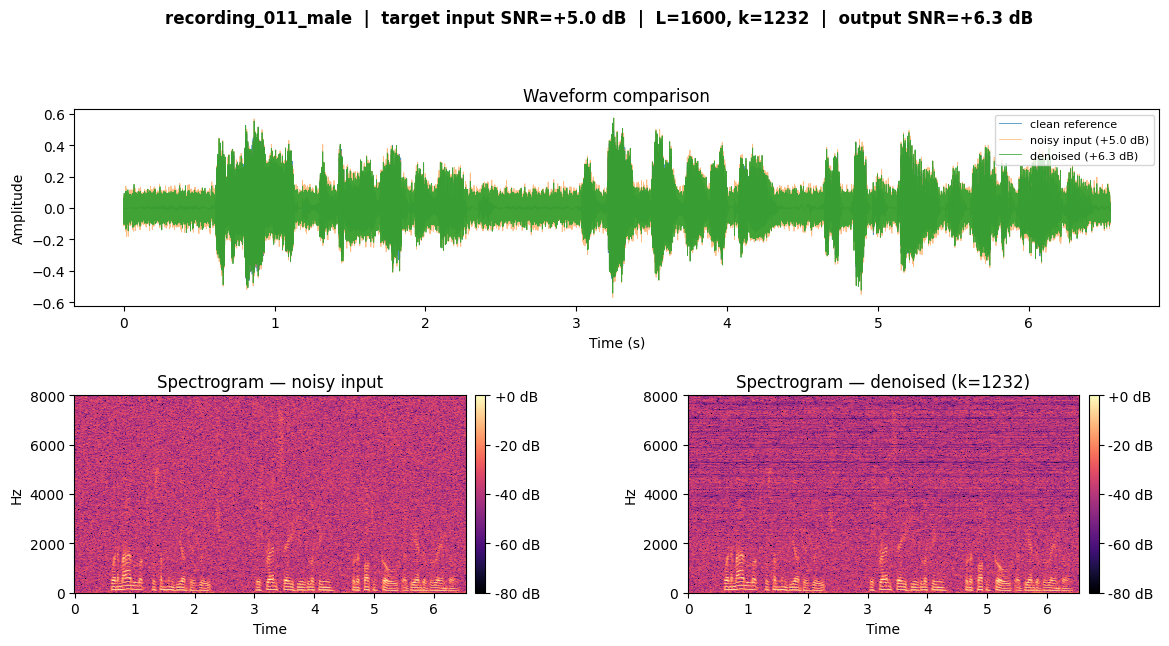

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── helpers ──────────────────────────────────────────────────────────────────

def rms(x):
    return np.sqrt(np.mean(x.astype(np.float64) ** 2))

def snr_db(reference, error):
    """Standard SNR = 10 log10(power(reference) / power(error))."""
    ps = np.mean(reference.astype(np.float64) ** 2)
    pe = np.mean(error.astype(np.float64) ** 2)
    if pe == 0:
        return np.inf
    return 10 * np.log10(ps / pe)

def spectral_centroid(x, sr):
    """Mean frequency weighted by power spectrum (Hz)."""
    freqs = np.fft.rfftfreq(len(x), d=1/sr)
    power = np.abs(np.fft.rfft(x.astype(np.float64))) ** 2
    return float(np.sum(freqs * power) / np.sum(power))

# ── scalar metrics ────────────────────────────────────────────────────────────

N_eval = min(len(clean_signal), len(signal), len(denoised))
clean_eval = clean_signal[:N_eval]
noisy_eval = signal[:N_eval]
denoised_eval = denoised[:N_eval].astype(np.float64)

input_noise = noisy_eval - clean_eval
output_error = denoised_eval - clean_eval

input_snr_eval_db = snr_db(clean_eval, input_noise)
output_snr_db = snr_db(clean_eval, output_error)
snr_improvement_db = output_snr_db - input_snr_eval_db
noise_power_reduction_pct = (1 - rms(output_error) ** 2 / rms(input_noise) ** 2) * 100
rms_vs_clean_pct = rms(denoised_eval) / rms(clean_eval) * 100

sc_clean = spectral_centroid(clean_eval, sr)
sc_noisy = spectral_centroid(noisy_eval, sr)
sc_denoised = spectral_centroid(denoised_eval, sr)
sc_shift_hz = sc_denoised - sc_clean

# singular-value energy breakdown
total_energy  = (s ** 2).sum()
kept_sv_energy_pct  = (s[:K_RANK] ** 2).sum() / total_energy * 100
noise_sv_energy_pct = 100 - kept_sv_energy_pct

print("=" * 52)
print(f"  k retained              : {K_RANK}  /  {len(s)}")
print(f"  SV energy kept          : {kept_sv_energy_pct:6.1f} %")
print(f"  SV energy discarded     : {noise_sv_energy_pct:6.1f} %")
print("-" * 52)
print(f"  Input SNR               : {input_snr_eval_db:+6.2f} dB")
print(f"  Output SNR              : {output_snr_db:+6.2f} dB")
print(f"  SNR improvement         : {snr_improvement_db:+6.2f} dB")

# ── visual evaluation ─────────────────────────────────────────────────────────

t = np.arange(N_eval) / sr

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f"{RECORDING_NAME}  |  target input SNR={TARGET_INPUT_SNR_DB:+.1f} dB  |  "
    f"L={L}, k={K_RANK}  |  output SNR={output_snr_db:+.1f} dB",
    fontsize=12, fontweight="bold"
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# --- waveforms ---
ax_w = fig.add_subplot(gs[0, :])
ax_w.plot(t, clean_eval, alpha=0.8, lw=0.6, label="clean reference")
ax_w.plot(t, noisy_eval, alpha=0.5, lw=0.6, label=f"noisy input ({input_snr_eval_db:+.1f} dB)")
ax_w.plot(t, denoised_eval, alpha=0.9, lw=0.6, label=f"denoised ({output_snr_db:+.1f} dB)")
ax_w.set_xlabel("Time (s)")
ax_w.set_ylabel("Amplitude")
ax_w.set_title("Waveform comparison")
ax_w.legend(loc="upper right", fontsize=8)

# --- spectrograms ---
def plot_spectrogram(ax, x, sr, title):
    n_fft = 1024
    hop   = 256
    S = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop,
                                   x_axis="time", y_axis="hz", ax=ax, cmap="magma")
    ax.set_title(title)
    ax.set_ylim(0, min(sr // 2, 8000))
    fig.colorbar(img, ax=ax, format="%+2.0f dB", pad=0.02)

plot_spectrogram(fig.add_subplot(gs[1, 0]), noisy_eval, sr, "Spectrogram — noisy input")
plot_spectrogram(fig.add_subplot(gs[1, 1]), denoised_eval, sr, f"Spectrogram — denoised (k={K_RANK})")

plt.show()